# Homework 1: Autoregressive models

## Task 1: Theory (5 pt)

### Problem 1: f-divergence (1 pt)

In [Lecture 1](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture1/Lecture1.pdf), we discussed that generative modeling can be formulated as minimizing a divergence between the data distribution $\pi$ and the model distribution $p_{\boldsymbol{\theta}}$. 

$$
	\min_{\boldsymbol{\theta}} D(\pi || p_{\boldsymbol{\theta}}),
$$

To study these behaviors in a unified way, it is convenient to use a broad family of divergences that contains many commonly used training objectives as special cases. One such family is the $f$-divergence family:
$$
	D_f(\pi || p_{\boldsymbol{\theta}}) = \mathbb{E}_{p_{\boldsymbol{\theta}}(\mathbf{x})} \Bigg[ f\left( \frac{\pi(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})} \right) \Bigg]  = \int p_{\boldsymbol{\theta}}(\mathbf{x}) f\left( \frac{\pi(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})} \right) d \mathbf{x},
$$
where $f: \mathbb{R}_+ \rightarrow \mathbb{R}$ is a function that is:
1. convex;
2. lower semicontinuous;
3. and satisfies $f(1)=0$.

> **Note:** It can be shown that for any function $f$ satisfying the conditions above, $D_f$ defines a valid divergence.

Your **task** is to show that the *forward* and *reverse KL divergences* belong to the $f$-divergence family. Identify the corresponding functions $f$ for each case and verify that they satisfy the conditions on $f$ stated above.

### Solution
#### 1
Forward KL: $D_{KL} (p_1 || p_2) = \int p_1(x) \log \frac{p_1(x)}{p_2(x)} dx$

Forward KL defines $f(x) = x \log x$ \
properties:
1. convex: hessian is positive definite on $(0, \infty)$

In [6]:
import sympy as sp
x = sp.symbols("x")
f = x * sp.log(x)
sp.diff(sp.diff(f, x), x)

1/x

2. lower semicontinuous: $x_0 \log x_0 \leq \lim_{x \to x_0} \inf (x \log x) = \lim_{x \to x_0} x \log x$ for every $x_0$ in domain of $f$
3. $f(1) = 1 \log 1 = 0$

#### 2
Reverse KL: $D_{KL} (p_2 || p_1) = \int p_2(x) \log \frac{p_2(x)}{p_1(x)} dx$ 

In terms of $f$-divergence Rverse KL defines $f(x) = \log x^{-1} = -\log x$ \
properties:
1. convex: $\log x$ is concave, so its negative is convex
2. lower semicontinuous: $-\log x_0 \leq \lim_{x \to x_0} \inf (-\log x) = \lim_{x \to x_0} \log x$ for every $x_0$ in domain of $f$
3. $f(1) = -\log 1 = 0$

### Problem 2: Curse of dimensionality (1 pt)

Many difficulties in generative modeling come from the fact that real data live in very high-dimensional spaces. This raises a crucial challenge in generative modeling: **the curse of dimensionality**. Let us build some intuition.

Consider a sphere of radius $r = 1$ in $\mathbb{R}^m$. Let say that it has the volume $V_m(r)$. Our goal is to find the fraction of the volume of the sphere that lies between radius $r = 1 - \epsilon$ and $r = 1$. Our geometric intuition is that this fraction is small. But the magic happens with $m$ goes to infinity. Basically, the volume of a high dimensional sphere is mostly in this small fraction!

This connects to two key issues:

- In practice, real data occupy only a tiny subset of all possible high-dimensional configurations ([the manifold hypothesis](https://en.wikipedia.org/wiki/Manifold_hypothesis)).
- Covering a high-dimensional space at a fixed resolution requires a number of samples that grows exponentially with dimension, roughly $\sim \mathcal{O}(c^m)$ for some $c>1$.

As a result, **learning accurate generative models in high dimensions is extremely challenging with finite data.**


Your **task** is:
1. Find (google it) the expression of the volume of a shpere of radius $r$ in $m$ dimensions.

2. Find the required fraction $\Delta = \frac{V_m(1) - V_m(1 - \epsilon)}{V_m(1)}$.

3. Prove that, for large $m$, the fraction tends to 1 even for small values of $\epsilon$.

### Solution

1. Formula for $n$-dimensional sphere: $V_n(r) = \frac{\pi^{n/2}}{\Gamma(n/2 + 1)} r^n$
2. Let $c = \frac{\pi^{m/2}}{\Gamma(m/2 + 1)}$, then $\Delta = 1 - (1 - \epsilon)^m$
3. $\lim_{m \to \infty} a^m = 0$ for $0 < a < 1$, hence $\lim_{m \to \infty} \Delta = 1$ for any $\epsilon > 0$

### Problem 3: Expressivity of normalizing flows (3 pts)

This problem considers the following question. Are normalizing flows able to represent **any** distribution $\pi(\mathbf{x})$, even if the base distribution $p(\mathbf{u})$ is restricted to be simple?

Let $\pi(\mathbf{x})$ is an absolutely continuous probability distribution supported everywhere on $\mathbb{R}^m$ (i.e. $\pi(\mathbf{x}) > 0$ for all $\mathbf{x} \in \mathbb{R}^m$). Additionally we suppose, that the pdf $\pi(\mathbf{x})$ is continuously differentiable on  $\mathbb{R}^m$.  Our ultimate goal is to show, that there exists diffeomorphism (invertible continuously differentiable map):
$$
    \mathbf{u} = F(\mathbf{x}) \quad F : \mathbb{R}^m \rightarrow \mathbb{U}.
$$
Here $\mathbb{U} = [0, 1]^m$ is a hypercube and $F$ turns $\pi(\mathbf{x})$ into uniform distribution $p(\mathbf{u}) = U[0, 1]^m$ on the hypercube $\mathbb{U}$ ($p(\mathbf{u}) = 1 \,,\, \mathbf{u} \in \mathbb{U}$). Here we have to think about openness and closeness of $\mathbb{U}$ for formal math correctness, but we omit it in this task. 

<details> 
  <summary> <i>Math correctness comment</i> </summary>
  
   Strictly speaking, the diffeomorphism $F$ maps $\mathbb{R}^m$ to the open cube $\text{int}\left(\mathbb{U}\right) = (0, 1)^m$, sinse the reverse mapping $F^{-1} : \text{int}\left(\mathbb{U}\right) \rightarrow \mathbb{R}^m$ is continuous $\Rightarrow$ the preimage of the open set $\mathbb{R}^m$ with respect to $F^{-1}$ should be <b>open</b>: $(F^{-1})^{-1}(\mathbb{R}^m) = F(\mathbb{R}^m) = \text{an open set}$
   
</details>

So, if such function exists, it means that **there exists normalizing flow model from base uniform distribution to any(!) target distribution.**

---------

1. Consider the autoregressive decomposition of $\pi(\mathbf{x})$:

$$
    \pi(\mathbf{x}) = \prod\limits_{j = 1}^{m} \pi(x_j|\mathbf{x}_{1:j - 1}).
$$

2. Treat each component $\pi(x_j|\mathbf{x}_{1:j - 1})$ in the decomposition above separately. Consider the transformations:

$$
    \mathbf{x} \rightarrow u_j = F_j(x_j, \mathbf{x}_{1:j - 1}) = \int\limits_{- \infty}^{x_j} \pi(x_j'|\mathbf{x}_{1:j - 1}) d x_j'.
$$

   Here $F_j(x_j, \mathbf{x}_{1:j - 1})$ is the cumulative distribution function of $j$-th conditional $x_j$ (given $\mathbf{x}_{1:j - 1}$) Note, that $u_j \in [0, 1]$.

3. Define the transform $F : \mathbb{R}^m \rightarrow \mathbb{U}$ as follows:
    
$$
    \mathbf{x} \rightarrow \mathbf{u} = \begin{bmatrix} F_1(x_1) \\ F_2(x_2,x_1) \\ \dots \\ F_m(x_m, \mathbf{x}_{1:m-1})\end{bmatrix}.
$$
    
Given the properties of $\pi$ ($\pi(\mathbf{x}) > 0$ and continuously differentiable) it is easy to show, that $F$ is continuously differentiable. We omit the details since they are just boring mathematical calculations.

1) Prove, that $\det \mathbf{J}_F (\mathbf{x}) = \pi(x)$ (it follows, that the function $F : \mathbb{R}^m \rightarrow \mathbb{U}$ is invertible).

2) Prove, that $\mathbf{u}$ is a uniformly distributed ($p(\mathbf{u}) = U[0,1]^m)$.

3) Let $\pi(\mathbf{x})$ and $\mu(\mathbf{y})$ are absolutely continuous probability distributions supported everywhere on $\mathbb{R}^m$, whose pdfs are continuously differentiable. Prove that there exists a diffeomorphism $G : \mathbb{R}^m \rightarrow \mathbb{R}^m$ which turns $\pi$ into $\mu$, i.e.:

$$\mathbf{y} = G(\mathbf{x}), \quad \text{where } \mathbf{x} \sim \pi(\mathbf{x}), \, \mathbf{y} \sim \mu(\mathbf{y}).$$

1. $\mathbf{J}_F(x)$ is lower-triangular (since u_j is a function of $\mathbf{x}_{1:j}$), so 
$$ \det \mathbf{J}_F(x) = \prod_{j=1}^m \frac{\partial u_j}{\partial x_j} = \prod_{j=1}^m \frac{\partial}{\partial x_j} \int_{-\infty}^{x_j} \pi(x_j'|\mathbf{x}_{1:j-1}) d x_j' = \prod_{j=1}^m \pi(x_j|\mathbf{x}_{1:j-1}) = \pi(x) $$
2. $p(\mathbf{u}) = \pi(\mathbf{x}) \left( \det \mathbf{J}_F \right)^{-1} = \pi(\mathbf{x}) \pi(\mathbf{x})^{-1} = 1$ - uniformly distributed on entire domain. Domain is $[0, 1]^m$ because of properties of CDF function $F$
3. Let $F_{\pi}$ and $F_{\mu}$ be diffeomorphisms mapping $\pi$ and $\mu$ into $\mathbf{u}$. Then, $G = F_{\mu}^{-1} \circ F_{\pi}$ is a diffeomorphism mapping $\pi$ into $\mu$.

Now it time to move on to practical part of homework.

In our course we will use a small util [package](https://github.com/r-isachenko/dgm_utils) with some usefull functions for loading and visualizing the images and training curves. In each homework there will be a cell with installing this package. Please read carefully the sources of the functions from this package. It could help you to solve the tasks.

In [1]:
COMMIT_HASH = "e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

Cloning into 'dgm_utils'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 219 (delta 143), reused 99 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (219/219), 52.84 KiB | 5.28 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/dgm_utils
Note: switching to 'e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at e0be9c3 Add grad clipping
Processing /

In [1]:
from dgm_utils import train_model
from dgm_utils import show_samples, visualize_images, load_dataset
from dgm_utils import BaseModel

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)') 
else: 
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 3: ImageGPT on MNIST (5 pts)

In this task you will try to implement the Image Transformer net for an autoregressive generation MNIST images. See the [blog](https://openai.com/blog/image-gpt/) and [paper](https://cdn.openai.com/papers/Generative_Pretraining_from_Pixels_V2.pdf) for details.

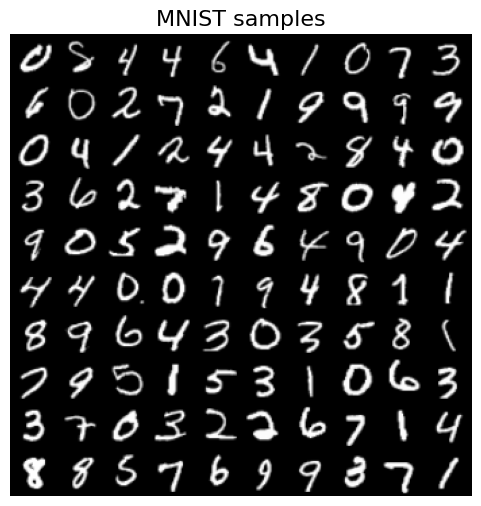

In [3]:
train_data, _, test_data, _ = load_dataset("mnist", flatten=False, binarize=False)
train_data, test_data = (train_data * 255).astype(int), (test_data * 255).astype(int)
visualize_images(train_data, "MNIST samples")

### Architecture

Let start with **the multihead attention block**. Each head of the multihead attention computes an embedding
$$
    \text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right) \mathbf{V},
$$
where $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ - query/key/value matrices obtained using Linear projection of $\mathbf{h}^l$.

**To make the model autoregressive** we will introduce the following changes:

1. We will apply the upper triangular mask to the matrix of attention logits ($\mathbf{Q}\mathbf{K}^T$). Masked values are made close to minus infinity so they will turn zero after softmax.
2. During training we will add "start of sequence" token to the input tensor and pop the last pixel.

Note: we will use raster order to identify which pixels come first (as we have done in PixelCNN). For each pixel the predicted probabality is conditioned on all the previous pixels.

In [4]:
class MultiheadAttention(nn.MultiheadAttention):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        super().__init__(embed_dim, num_heads)

    def get_attention_mask(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # define attention mask, it should contain
        # - zeros under and on the main diagonal
        # - minus Inf above the main diagonal

        # ====
        size, *_ = x.shape
        attn_mask = torch.triu(torch.full((size, size), float("-inf"), device=x.device), diagonal=1)
        return attn_mask

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_mask = self.get_attention_mask(x)
        return super().forward(x, x, x, attn_mask=attn_mask, need_weights=False)[0]


def test_attention_mask() -> None:
    x = torch.zeros(2, 4, 16)  # (pixel_num, batch_size, emb_dim)
    mask = np.array([[0.0, -np.inf], [0.0, 0.0]])
    layer = MultiheadAttention(16, 8)
    attention_mask = layer.get_attention_mask(x)
    assert attention_mask.size() == (x.size(0), x.size(0))
    assert np.allclose(attention_mask.numpy(), mask)
    out = layer(x)
    assert x.size() == out.size()


test_attention_mask()

Now we will define **the decoder block** wich transformes the tensor as follows:
\begin{gather}
    \mathbf{n}^l = \text{layer\_norm}_1\left(\mathbf{h}^l\right), \notag \\
    \mathbf{a}^l = \mathbf{h}^l + \text{multihead\_attention}\left(\mathbf{n}^l\right), \notag \\
    \mathbf{h}^{l+1} = \mathbf{a}^l + \text{MLP}\left(\text{layer\_norm}_2\left(a^l\right)\right). \notag
\end{gather}

The $l^{\text{th}}$ block receives a tensor $\mathbf{h}^l$ with shape `(pixel_num, batch_size, emb_dim)` where `pixel_num` is a total number of pixels $(28*28)$ and `emb_dim` is a hyperparameter for the size of the embeddings.

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        super().__init__()
        assert embed_dim % num_heads == 0

        # ====
        # your code
        # define basic layers of Transformer:
        # 1. our masked MultiheadAttention
        # 2. LayerNorm (https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
        # 3. some MLP

        # ====
        self.norm1 = nn.RMSNorm(embed_dim)
        self.mha = MultiheadAttention(embed_dim, num_heads)
        self.norm2 = nn.RMSNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # here you have to implement formulas that described above.

        # ====
        x = x + self.mha(self.norm1(x))
        return x + self.ffn(self.norm2(x))


def test_decoder_block() -> None:
    block = TransformerBlock(embed_dim=12, num_heads=4)
    x = torch.zeros(4, 28, 12)
    assert x.shape == block(x).shape


test_decoder_block()

Finally, let's construct the Image Transformer. It consists of $L$ sequentially applied decoder blocks.

The initial embedding $h^1$ is the sum of the token embedding of the input batch and a trainable positional embedding, with a "start of sequence" token prepended. 

After passing through the last decoder block, we apply `nn.LayerNorm` followed by a `nn.Linear` layer to produce logits of shape `(pixel_num, batch_size, 1)`:

$$
\begin{align*}
  n^L &= \text{layer\_norm}\left(h^L\right) \\
  \text{logits} &= \text{linear}\left(n^L\right)
\end{align*}
$$

In [6]:
class ImageGPT(BaseModel):
    def __init__(
        self, input_shape: tuple[int, int], embed_dim: int, num_heads: int, num_layers: int
    ) -> None:
        super().__init__()

        self.embed_dim = embed_dim
        self.input_shape = input_shape
        self.criterion = nn.CrossEntropyLoss()

        # "start of sequence" token (we initialize it from Normal distribution)
        self.sos = nn.Parameter(0.02 * torch.randn(embed_dim))
        

        # ====
        # your code
        # 1) define token_embeddings (we will have 256 embeddings in total, because pixels in range [0, 255])
        # 2) define position_embeddings (we will use nn.Embedding)

        # ====
        self.token_embeddings = nn.Embedding(256, embed_dim)
        self.position_embeddings = nn.Embedding(input_shape[0] * input_shape[1], embed_dim)

        # ====
        # your code
        # 1) add decoder blocks to self.layers list
        # 2) define last LayerNorm
        # 3) define final Linear layer (without bias)

        # ====
        self.layers = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)])
        self.norm = nn.RMSNorm(embed_dim)
        self.proj = nn.Linear(embed_dim, 256, bias=False)

    def add_sos_token(self, embeddings: torch.Tensor) -> torch.Tensor:
        batch_size = embeddings.size(1)
        # ====
        # your code
        # prepend sos (start of sequence) token
        # 1) repeat sos token batch_size times (make it of size (1, batch_size, emd_size))
        # 2) drop last embedding from embeddings
        # 3) concat repeated sos token to embeddings (after dropping)

        # ====
        return torch.cat([self.sos[None, None, :].repeat(1, batch_size, 1), embeddings[:-1]], dim=0)

    def add_pos_embeddings(self, embeddings: torch.Tensor) -> torch.Tensor:
        length = embeddings.size(0)
        # ====
        # your code
        # add positional embeddings
        # 1) define tensor with positions (just torch.arange) of size (length, 1)
        # 2) add position embeddings to initial embeddings

        # ====
        return embeddings + self.position_embeddings(torch.arange(length, device=embeddings.device)[:, None])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.long()
        x = x.reshape(x.size(0), -1)  # (batch_size, length)
        x = x.permute(1, 0)

        embeddings = self.token_embeddings(x)  # (length, batch_size, emb_size)
        embeddings = self.add_sos_token(embeddings)
        embeddings = self.add_pos_embeddings(embeddings)

        # ====
        # your code
        # 1) apply all decoder layers
        # 2) apply final LayerNorm and Linear layer

        # ====
        for layer in self.layers:
            embeddings = layer(embeddings)

        embeddings = self.norm(embeddings)
        return self.proj(embeddings).permute(1, 0, 2)  # (length, batch_size, emb_size) -> (batch_size, length, emb_size)

    def loss(self, x: torch.Tensor) -> dict:
        logits = self(x)
        loss = self.criterion(logits.reshape(-1, 256), x.reshape(-1).long())
        return {"total_loss": loss}

    @torch.no_grad()
    def sample(self, n_samples: int) -> np.ndarray:
        # read sampling carefully
        seq_len = self.input_shape[0] * self.input_shape[1]
        samples = torch.zeros(n_samples, seq_len).long().to(self.device)
        for i in range(seq_len):
            logits = self(samples)
            dist = torch.distributions.Categorical(logits=logits[:, i, :])
            samples[:, i] = dist.sample()
        samples = samples.reshape(n_samples, 1, *self.input_shape)
        return samples.cpu().numpy()

def test_image_gpt():
    batch_size, size = 8, 2
    seq_len = size * size
    embed_dim = 12
    image_gpt = ImageGPT(
        input_shape=(size, size), 
        embed_dim=embed_dim, 
        num_heads=4, 
        num_layers=2
    )
    emb = torch.randn(seq_len, batch_size, embed_dim)
    out = image_gpt.add_sos_token(emb)
    assert torch.isclose(out[0, 0, :], image_gpt.sos).all(), \
        "First token must equal the SOS embedding for every batch element."
    assert torch.allclose(out[1:], emb[:-1]), \
        "Sequence must be shifted right by 1."

    with torch.no_grad():
        for p in range(seq_len):
            image_gpt.position_embeddings.weight[p].fill_(float(p))

    emb = torch.zeros(seq_len, batch_size, embed_dim)
    out = image_gpt.add_pos_embeddings(emb)

    for p in range(seq_len):
        expected = torch.full((batch_size, embed_dim), p, dtype=emb.dtype)
        assert torch.allclose(out[p], expected), (
            f"Position {p} must add a vector filled with {p} to all batch elements."
        )


    x = torch.randint(0, 256, size=(batch_size, seq_len))
    assert image_gpt(x).shape == torch.Size([batch_size, seq_len, 256]), \
        "Output must have shape (batch_size, seq_len, 256) for 256-class pixels."

test_image_gpt()

### Training

Now we are ready to train our model.

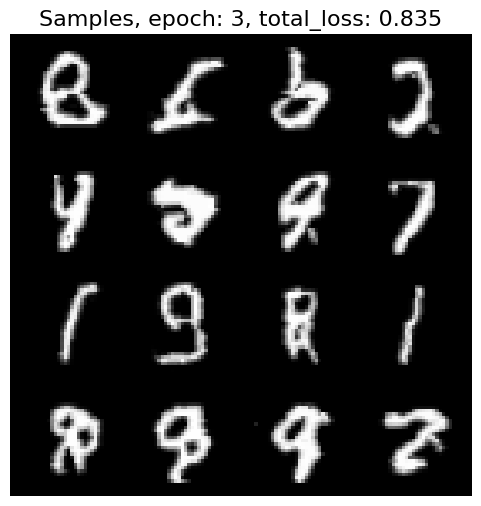

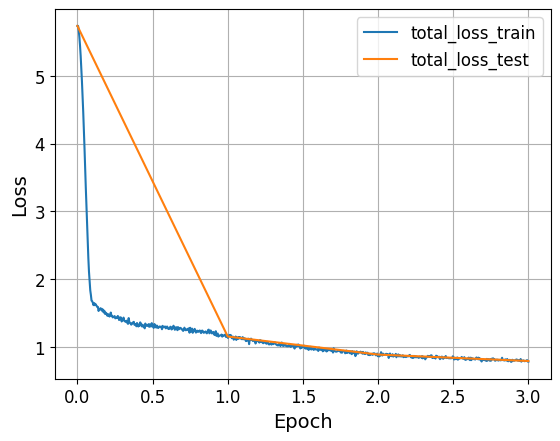

End of the training


In [ ]:
# ====
# your code
# choose these parameters
EPOCHS = 3
BATCH_SIZE = 256
LR = 2e-2

EMB_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
# ====

image_gpt = ImageGPT((32, 32), EMB_DIM, NUM_HEADS, NUM_LAYERS)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)



def newtonschulz5(G, steps=5, eps=1e-7):
    assert G.ndim == 2
    orig_dtype = G.dtype
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X /= X.norm() + eps
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(orig_dtype)


class Muon(torch.optim.Optimizer):
    def __init__(
        self,
        params,
        lr: float = 2e-2,
        beta: float = 0.95,
        weight_decay: float = 0.01,
        ns_steps: int = 5,
    ):
        defaults = dict(lr=lr, beta=beta, weight_decay=weight_decay, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr = group["lr"]
            beta = group["beta"]
            weight_decay = group["weight_decay"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.mul_(1 - lr * weight_decay)

                state = self.state[p]

                if "momentum" not in state:
                    state["momentum"] = torch.zeros_like(p)

                g = p.grad
                m = state["momentum"]

                if g.ndim == 2:
                    g = newtonschulz5(g, ns_steps)
                elif g.ndim > 2:
                    orig_shape = g.shape
                    g = g.view(g.shape[0], -1)
                    g = newtonschulz5(g, ns_steps)
                    g = g.view(orig_shape)

                m.lerp_(g, 1 - beta)
                g.lerp_(m, beta)
                p.add_(g, alpha=-lr)

optimizer = Muon(image_gpt.parameters(), lr=LR, beta=0.95, weight_decay=0.01, ns_steps=5)

train_model(
    image_gpt,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16, # Remember the infernce is slow, so, you can lower the value 
    visualize_samples=True, # or you can turn off smapling by setting `visualize_samples=False`
    use_amp=True
)

Let sample from our model. You probably get better samples than PixelCNN samples.

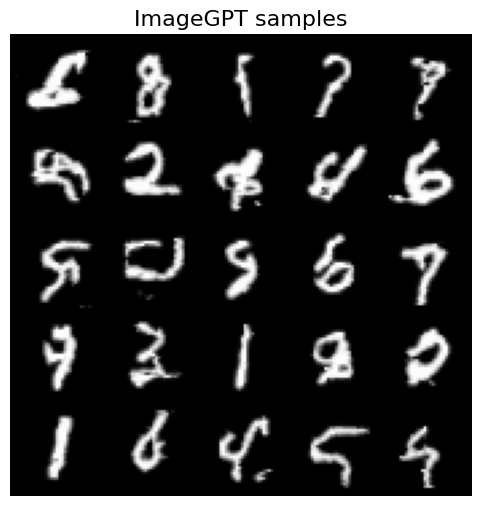

In [8]:
samples = image_gpt.sample(25)
show_samples(samples, title="ImageGPT samples", nrow=5)

## Task 3: RealNVP on MNIST (5 pts)

In this task, you will **implement RealNVP** for MNIST dataset. See [Lecture 2](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture2/Lecture2.pdf), [Seminar 2](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/seminars/seminar2/seminar2.ipynb) and [paper](https://arxiv.org/abs/1605.08803) for details.

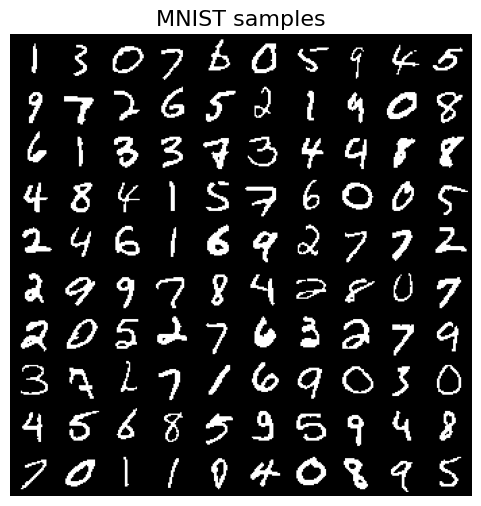

In [14]:
train_data, _, test_data, _ = load_dataset("mnist", flatten=False, binarize=True)
visualize_images(train_data.astype(float), "MNIST samples")

Please note that our data is **discrete**, and, moreover, it is **binary**. This is done to simplify the learning task.

In this task for the neural networks $s(\cdot)$ and $t(\cdot)$ we will use the ResNet-like network. The model will consist stack of Residual blocks:
$$
    \mathbf{y} = \mathbf{x} + f(\mathbf{x}).
$$

In [15]:
class GatedConv(nn.Module):
    def __init__(self, n_filters):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, kernel_size=3, padding=1),
            nn.ELU(),
            nn.Conv2d(n_filters, 2*n_filters, kernel_size=1),
            nn.ELU()
        )
    
    def forward(self, x):
        out = self.net(x)
        val, gate = out.chunk(2, dim=1)
        return x + val * torch.sigmoid(gate)


class SimpleResnet(nn.Module):
    def __init__(
        self, in_channels: int, out_channels: int, n_filters: int, n_blocks: int
    ) -> None:
        super().__init__()
        # you could experiment with this architecture
        layers = [
            nn.Conv2d(in_channels, n_filters, kernel_size=3, padding=1),
            nn.ELU()
        ]
        for _ in range(n_blocks):
            layers.extend([
                GatedConv(n_filters),
                nn.ELU()
            ])
        layers.append(nn.Conv2d(n_filters, out_channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

We have to implement coupling layer for images. To split image in two parts we will you **checkerboard** and **chanelwise** splitting (see image below).

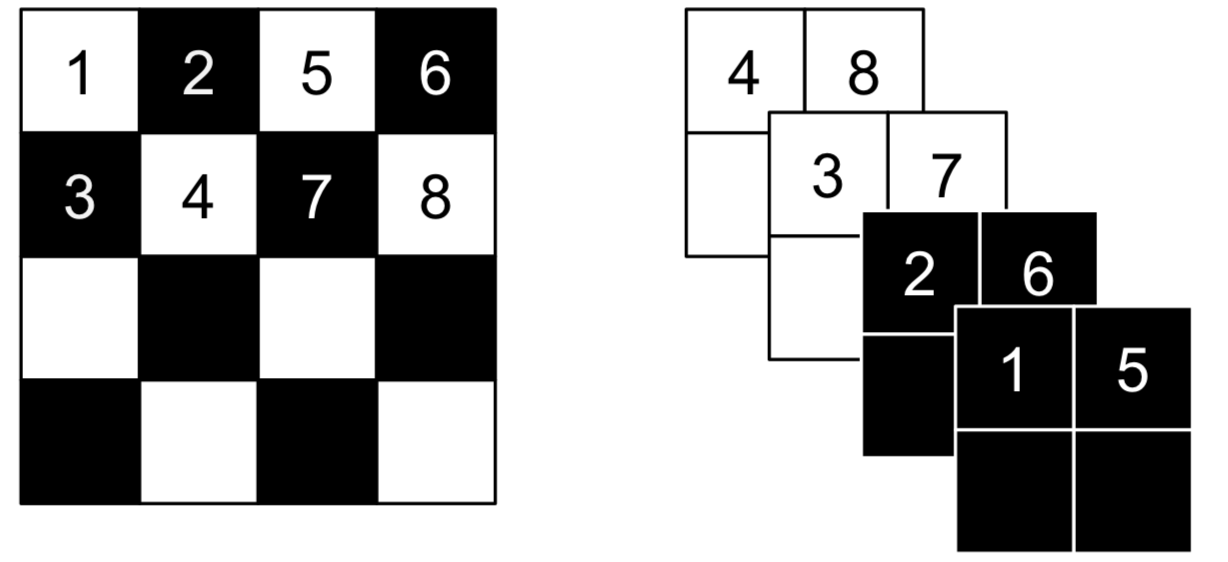

Firstly, let implement checkerboard splitting.

In [ ]:
class AffineCheckerboardCouplingLayer(nn.Module):
    def __init__(
        self,
        parity_type: bool,
        input_shape: tuple,
        in_channels: int = 3,
        n_filters: int = 32,
        n_blocks: int = 4,
    ) -> None:
        assert isinstance(parity_type, bool)
        super().__init__()
        self.input_shape = input_shape
        self.parity_type = parity_type
        self.mask = self.build_mask()
        self.scale = nn.Parameter(torch.zeros(1), requires_grad=True)
        self.scale_shift = nn.Parameter(torch.zeros(1), requires_grad=True)

        # ====
        # your code
        # define resnet that will output s() and t()

        # ====
        self.resnet = SimpleResnet(in_channels=in_channels, out_channels=in_channels * 2, n_filters=n_filters, n_blocks=n_blocks)

    def build_mask(self) -> torch.Tensor:
        # ====
        # your code
        # return checkerboard mask
        # if parity_type == True, the top left corner will be 1.0
        # if parity_type == False, the top left corner will be 0.0

        # ====
        h, w = self.input_shape
        base = (np.indices((h, w)).sum(axis=0) % 2).astype(np.float32)  # top-left = 0
        if self.parity_type:
            base = 1.0 - base
        mask = base[None, None, :, :]
        assert mask.shape[1:] == (1, *self.input_shape)
        return torch.tensor(mask)

    def forward(self, x: torch.Tensor, invert: bool = False) -> tuple:
        mask = self.mask.to(x.device)

        # ====
        # your code
        # 1) mask tensor x
        # 2) apply resnet to masked x
        # 3) split resnet output to get s and t

        # ====
        x_masked = x * mask
        s_t = self.resnet(x_masked)
        s, t = torch.chunk(s_t, 2, dim=1)

        # this formula is described in Section 4.1 in original paper
        # just left it unchanged
        s = self.scale * torch.tanh(s) + self.scale_shift
        t = t * (1.0 - mask)
        s = s * (1.0 - mask)

        # ====
        # your code
        # apply forward (invert=False) or inverse (invert=True) transform

        # ====
        if not invert:
            z = x_masked + (1.0 - mask) * (x * torch.exp(s) + t)
        else:
            z = x_masked + (1.0 - mask) * ((x - t) * torch.exp(-s))

        return z, s


def test_affine_checkerboard_coupling_layer():
    x = torch.zeros((1, 1, 2, 2), dtype=torch.float32)

    layer = AffineCheckerboardCouplingLayer(parity_type=True, input_shape=(2, 2), in_channels=1, n_filters=4, n_blocks=1)
    x = x.to(DEVICE)
    layer = layer.to(DEVICE)
    mask = np.array([[1, 0], [0, 1]], dtype=np.float32)
    out1, out2 = layer(x)
    assert tuple(out1.size()) == (1, 1, 2, 2)
    assert tuple(out2.size()) == (1, 1, 2, 2)

    assert np.allclose(out1.cpu().detach().numpy()[0, 0] * mask, np.zeros((2, 2)))
    assert np.allclose(out2.cpu().detach().numpy()[0, 0], np.zeros((2, 2)))

    layer = AffineCheckerboardCouplingLayer(parity_type=False, input_shape=(2, 2), in_channels=1, n_filters=4, n_blocks=1)
    layer = layer.to(DEVICE)
    mask = np.array([[0, 1], [1, 0]], dtype=np.float32)
    out1, out2 = layer(x)
    assert tuple(out1.size()) == (1, 1, 2, 2)
    assert tuple(out2.size()) == (1, 1, 2, 2)

    assert np.allclose(out1.cpu().detach().numpy()[0, 0] * mask, np.zeros((2, 2)))
    assert np.allclose(out2.cpu().detach().numpy()[0, 0], np.zeros((2, 2)))


test_affine_checkerboard_coupling_layer()

Secodly, let implement channelwise splitting.

In [19]:
class AffineChannelCouplingLayer(nn.Module):
    def __init__(
        self,
        parity_type: bool,
        in_channels: int = 6,
        n_filters: int = 32,
        n_blocks: int = 4,
    ) -> None:
        assert isinstance(parity_type, bool)
        super().__init__()
        self.parity_type = parity_type
        self.scale = nn.Parameter(torch.zeros(1), requires_grad=True)
        self.scale_shift = nn.Parameter(torch.zeros(1), requires_grad=True)
        # ====
        # your code
        # define resnet that will output s() and t()

        # ====
        self.resnet = SimpleResnet(in_channels=in_channels, out_channels=in_channels * 2, n_filters=n_filters, n_blocks=n_blocks)

    def forward(self, x: torch.Tensor, invert: bool = False) -> torch.Tensor:
        n_channels = x.shape[1]

        # ====
        # your code
        # 1) split x to two equal parts by channel dimension (dim=1)
        # 2) apply resnet to masked x
        # 3) split resnet output to get s and t

        # ====
        if self.parity_type:
            z, z_split = torch.chunk(x, chunks=2, dim=1)
        else:
            z_split, z = torch.chunk(x, chunks=2, dim=1)

        s_t = self.resnet(z_split)
        s, t = torch.chunk(s_t, chunks=2, dim=1)

        # this formula is described in Section 4.1 in original paper
        # just left it unchanged
        s = self.scale * torch.tanh(s) + self.scale_shift

        # ====
        # your code
        # apply forward (invert=False) or inverse (invert=True) transform

        # ====
        if invert:
            z = (z - t) * torch.exp(-s)
        else:
            z = z * torch.exp(s) + t

        # look carefully at this piece of code
        if self.parity_type:
            z = torch.cat([z, z_split], dim=1)
            s = torch.cat([s, torch.zeros_like(s)], dim=1)
        else:
            z = torch.cat([z_split, z], dim=1)
            s = torch.cat([torch.zeros_like(s), s], dim=1)
        return z, s


def test_affine_channel_coupling_layer():
    x = torch.zeros((1, 4, 2, 2), dtype=torch.float32)

    layer = AffineChannelCouplingLayer(parity_type=True, in_channels=2, n_filters=4, n_blocks=1)
    x = x.to(DEVICE)
    layer = layer.to(DEVICE)

    mask = np.array(
        [[[0, 0], [0, 0]], [[0, 0], [0, 0]], [[1, 1], [1, 1]], [[1, 1], [1, 1]]],
        dtype=np.float32,
    )
    out1, out2 = layer(x)
    assert tuple(out1.size()) == (1, 4, 2, 2)
    assert tuple(out2.size()) == (1, 4, 2, 2)

    assert np.allclose(out1.cpu().detach().numpy()[0] * mask, np.zeros((4, 2, 2)))
    assert np.allclose(out2.cpu().detach().numpy()[0, 0], np.zeros((4, 2, 2)))

    layer = AffineChannelCouplingLayer(parity_type=False, in_channels=2, n_filters=4, n_blocks=1)
    layer = layer.to(DEVICE)

    mask = np.array(
        [[[1, 1], [1, 1]], [[1, 1], [1, 1]], [[0, 0], [0, 0]], [[0, 0], [0, 0]]],
        dtype=np.float32,
    )
    out1, out2 = layer(x)
    assert tuple(out1.size()) == (1, 4, 2, 2)
    assert tuple(out2.size()) == (1, 4, 2, 2)

    assert np.allclose(out1.cpu().detach().numpy()[0, 0] * mask, np.zeros((4, 2, 2)))
    assert np.allclose(out2.cpu().detach().numpy()[0, 0], np.zeros((4, 2, 2)))


test_affine_channel_coupling_layer()

We will use the following normalization layer for more stable training. Look carefully at the class below (do not chage it).

In [20]:
class ActNormLayer(nn.Module):
    def __init__(self, n_channels: int) -> None:
        super().__init__()
        self.log_scale = nn.Parameter(torch.zeros(1, n_channels, 1, 1), requires_grad=True)
        self.shift = nn.Parameter(torch.zeros(1, n_channels, 1, 1), requires_grad=True)
        self.n_channels = n_channels
        self.initialized = False

    def forward(self, x: torch.Tensor, invert: bool = False) -> torch.Tensor:
        if invert:
            return (x - self.shift) * torch.exp(-self.log_scale), self.log_scale
        else:
            if not self.initialized:
                self.shift.data = -torch.mean(x, dim=[0, 2, 3], keepdim=True)
                self.log_scale.data = -torch.log(torch.std(x.permute(1, 0, 2, 3).reshape(self.n_channels, -1), dim=1).reshape(1, self.n_channels, 1, 1))
                self.initialized = True
            return x * torch.exp(self.log_scale) + self.shift, self.log_scale

Our data is discrete. The normalizing flow model works with continuous data (it is a requirement of CoV theorem).

Therefore, we have to convert our discrete data to continuous one. This process is called **dequantization**. We will discuss it in Lecture 5.

To dequantize the discrete variable $x \in \{0, 1, \dots, K - 1\}$ we add uniform noise to it:
$$
    y = x + u, \quad u \sim \text{Uniform}[0, 1].
$$

Then random variable $y \in [0, K]$ will be continuous and in fact similar to $x$.

Let implement simple function for such dequantization.

In [21]:
def dequantize(x: torch.Tensor, nbins: int = 256) -> torch.Tensor:
    return (x * (nbins - 1) + torch.distributions.Uniform(0.0, 1.0).sample(x.shape).to(x.device)) / nbins

The second issue that we will address here is the boundedness of the image domain. It is more natural for the model to fit the data from the range $(-\infty, +\infty)$.

The most natural way to convert $(-\infty, +\infty)$ range to the $[0, 1]$ is to apply sigmoid function. But here we need the inverse transform from [0, 1] range (it is normalized dequantized images) to $(-\infty, +\infty)$. So we need to apply inverse sigmoid function. This function is called logit:
$$
    \text{logit}(x) = \log \left( \frac{x}{1 - x} \right) = \log (x) - \log (1 - x).
$$

The last note here is the stability of this transform. To make it stable the common practice is to convert [0, 1] range to the $[\alpha, 1 - \alpha]$ firstly (where $\alpha$ is a small constant):
$$
    \text{logit}(x) = \log (y) - \log (1 - y), \quad \text{where } y = \alpha + (1 - 2 * \alpha) * x.
$$

Also we need the logarithm of the Jacobian' determinant for this transform. We implement this for you, but we really encourage you to check that the formula in the code is correct for better understanding.

In [22]:
class LogitTransform(nn.Module):
    def __init__(
        self, alpha: float = 1e-6, dequantize: bool = True, nbins: int = 256
    ) -> None:
        super().__init__()
        self.alpha = alpha
        self.dequantize = dequantize
        self.nbins = nbins

    def forward(self, x: torch.Tensor, invert: bool = False) -> tuple:
        if invert:
            log_det = (
                -x - 2 * F.softplus(-x) - torch.log(torch.tensor(1 - 2 * self.alpha))
            )
            x = (torch.sigmoid(x) - self.alpha) / (1 - 2 * self.alpha)
        else:
            # dequantization
            if self.dequantize:
                x = dequantize(x, nbins=self.nbins)

            # ====
            # your code
            # 1) scale the data to [alpha, 1 - alpha range] (save the result to x_scaled)
            # 2) apply logit operation that described above (save the result to x)

            # ====
            x_scaled = self.alpha + (1.0 - 2.0 * self.alpha) * x
            x = torch.log(x_scaled) - torch.log(1.0 - x_scaled)

            # look carefully at this expression, try to understand this formula
            log_det = (
                -torch.log(x_scaled)
                - torch.log(1.0 - x_scaled)
                + torch.log(torch.tensor(1 - 2 * self.alpha))
            )
        return x, log_det


def test_logit_transform():
    layer = LogitTransform(alpha=0.05, dequantize=False)
    x = torch.tensor((0, 1, 2, 3)) / 256.0
    z, log_det = layer(x)
    assert np.allclose(
        z.cpu().detach().numpy(),
        np.array([-2.944439, -2.8727808, -2.8054335, -2.7418802]),
    )
    assert np.allclose(
        log_det.cpu().detach().numpy(),
        np.array([2.9416652, 2.8774219, 2.8175175, 2.7614343]),
    )

    x_restored, _ = layer(z, invert=True)
    assert np.allclose(x.cpu().detach().numpy(), x_restored.cpu().detach().numpy())


test_logit_transform()

Not it is time to define the final model.

The model will consist of several blocks:

1. Logit Transform (to convert the data to $(-\infty, \infty)$ range).
2. Stack of checkerboard coupling layers.
3. Squeeze operation (convert tensor $[B, C, H, W]$ to $[B, 4 * C, H / 2, W / 2]$).
4. Stack of channelwise coupling layers
5. Unsqueeze operation (convert tensor $[B, C, H, W]$ to $[B, C / 4, 2 * H, 2 * W]$).
2. Stack of checkerboard coupling layers.

In [25]:
class RealNVP(BaseModel):
    def __init__(self, input_shape: tuple, n_channels: int, n_filters: int, n_blocks: int, nbins: int = 256) -> None:
        super().__init__()
        self.input_shape = input_shape
        self.n_channels = n_channels
        self.nbins = nbins

        self.prior = torch.distributions.Normal(loc=torch.tensor(0.0), scale=torch.tensor(1.0))
        self.logit_transform = LogitTransform(nbins=nbins, dequantize=True)

        # ====
        # your code
        # define stack of checkerboard coupling layers with alternating parity_type
        # add ActNormLayer after each coupling layer

        # ====
        self.transforms1 = nn.ModuleList()
        for _ in range(n_blocks):
            self.transforms1.append(AffineCheckerboardCouplingLayer(parity_type=True, input_shape=input_shape, in_channels=n_channels, n_filters=n_filters, n_blocks=n_blocks))
            self.transforms1.append(ActNormLayer(n_channels=n_channels))

        # ====
        # your code
        # define stack of channel coupling layers with alternating parity_type
        # add ActNormLayer after each coupling layer

        # ====
        self.transforms2 = nn.ModuleList()
        for i in range(n_blocks):
            parity = (i % 2 == 0)
            self.transforms2.append(
                AffineChannelCouplingLayer(
                    parity_type=parity,
                    in_channels=2 * n_channels,
                    n_filters=n_filters,
                    n_blocks=n_blocks,
                )
            )
            self.transforms2.append(ActNormLayer(n_channels=4 * n_channels))

        # ====
        # your code
        # define stack of checkerboard coupling layers with alternating parity_type
        # add ActNormLayer after each coupling layer

        # ====
        self.transforms3 = nn.ModuleList()
        for _ in range(n_blocks):
            self.transforms3.append(AffineCheckerboardCouplingLayer(parity_type=False, input_shape=input_shape, in_channels=n_channels, n_filters=n_filters, n_blocks=n_blocks))
            self.transforms3.append(ActNormLayer(n_channels=n_channels))

    def squeeze(self, x: torch.Tensor) -> torch.Tensor:
        # Look carefully at this piece of code (do not change)
        [B, C, H, W] = list(x.size())
        x = x.reshape(B, C, H // 2, 2, W // 2, 2)
        x = x.permute(0, 1, 3, 5, 2, 4)
        x = x.reshape(B, C * 4, H // 2, W // 2)
        return x

    def undo_squeeze(self, x: torch.Tensor) -> torch.Tensor:
        # Look carefully at this piece of code (do not change)
        [B, C, H, W] = list(x.size())
        x = x.reshape(B, C // 4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3)
        x = x.reshape(B, C // 4, H * 2, W * 2)
        return x

    def forward(self, x: torch.Tensor, invert: bool = False) -> tuple:
        z = x
        log_det = torch.zeros_like(x)
        if invert:
            for op in reversed(self.transforms3):
                z, delta_log_det = op.forward(z, invert=True)
                log_det = log_det + delta_log_det
            z, log_det = self.squeeze(z), self.squeeze(log_det)
            for op in reversed(self.transforms2):
                z, delta_log_det = op.forward(z, invert=True)
                log_det = log_det + delta_log_det
            z, log_det = self.undo_squeeze(z), self.undo_squeeze(log_det)
            for op in reversed(self.transforms1):
                z, delta_log_det = op.forward(z, invert=True)
                log_det = log_det + delta_log_det
            z, delta_log_det = self.logit_transform(z, invert=True)
            log_det = log_det + delta_log_det
        else:
            z, delta_log_det = self.logit_transform(z)
            log_det = log_det + delta_log_det
            for op in self.transforms1:
                z, delta_log_det = op.forward(z)
                log_det = log_det + delta_log_det
            z, log_det = self.squeeze(z), self.squeeze(log_det)
            for op in self.transforms2:
                z, delta_log_det = op.forward(z)
                log_det = log_det + delta_log_det
            z, log_det = self.undo_squeeze(z), self.undo_squeeze(log_det)
            for op in self.transforms3:
                z, delta_log_det = op.forward(z)
                log_det = log_det + delta_log_det
        return z, log_det

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        self.prior.loc = self.prior.loc.to(self.device)
        self.prior.scale = self.prior.scale.to(self.device)
        # ====
        # your code
        # 1) make forward pass with right inverse flag
        # 2) sum log_det with log of base distribution (log p(z))
        # 3) we will get tensor of shape [batch_size, 3, H, W] - sum it over the the last 3 dimensions

        # ====
        z, log_det = self.forward(x, invert=False)
        log_prob = self.prior.log_prob(z)
        return (log_prob + log_det).sum(dim=[1, 2, 3])

    def loss(self, x: torch.Tensor) -> dict:
        return {"nll_loss": -self.log_prob(x).mean()}

    def sample(self, num_samples: int) -> np.ndarray:
        self.prior.loc = self.prior.loc.to(self.device)
        self.prior.scale = self.prior.scale.to(self.device)
        # Look carefully at this piece of code (do not change)
        z = self.prior.sample([num_samples, self.n_channels, *self.input_shape])
        samples = self.forward(z, invert=True)[0]
        samples = samples.cpu().detach().numpy()
        samples = np.floor(np.clip(samples * self.nbins, 0.0, self.nbins - 1)) / (self.nbins - 1)
        return samples

Let train this model :)

The model can be challenging to train, so don't be discouraged by poor initial samples. For better results, train the model for more than an hour.

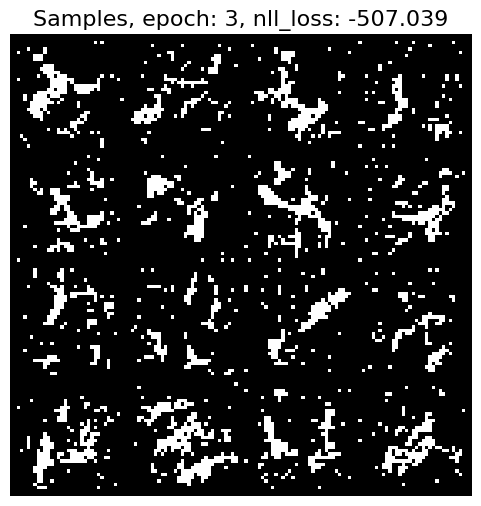

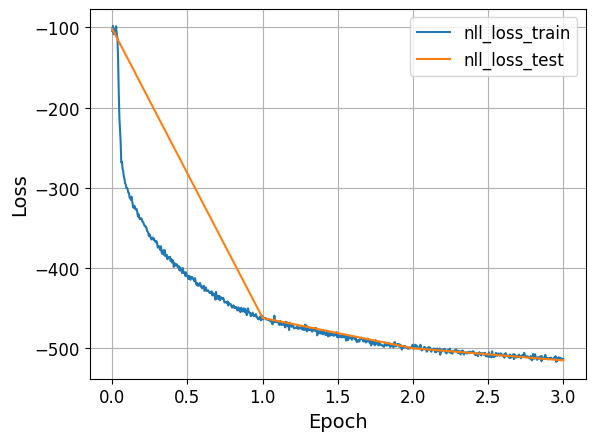

End of the training


In [26]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 256
LR = 2e-2
EPOCHS = 3
N_FILTERS = 64
N_BLOCKS = 4
# ====

# model
model = RealNVP(
    input_shape=(32, 32), 
    n_channels=1, 
    n_filters=N_FILTERS, 
    n_blocks=N_BLOCKS, 
    nbins=2
)

loader_args = dict(batch_size=BATCH_SIZE, shuffle=True)
train_loader = data.DataLoader(train_data, **loader_args)
test_loader = data.DataLoader(test_data, **loader_args)

# ====
# your code
# choose any optimizer/scheduler as you want
optimizer = Muon(model.parameters(), lr=LR)
# ====

# train
train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    gradient_clip_val=1.0,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
    loss_key="nll_loss",
    use_amp=True
)